# $Neural-Networks$

## Neuron
- Neuron is a single unit of a neural network
- Multiple neurons combine to form a neural network

![](https://storage.googleapis.com/kaggle-media/learn/images/mfOlDR6.png)
Linear Unit : **y = wx + b**
- 
- Bias - a kind of special weight. This helps activate a neuron independently of a input
- Especially if the input = 0, then bias decides the output

If there are mulitple inputs to deal with:

![](https://storage.googleapis.com/kaggle-media/learn/images/vyXSnlZ.png)

- Let's implement this using a python framework - Tensorflow

In [2]:
# pip install tensorflow

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Dense(units = 1, # single neuron
    input_shape = [4])        # take single input
])



## **Neural Networks**

- A combination of multiple neuron units
- We can arrange multiple layers of these neurons as well
- There are three types of layers:
1. **Input Layer**
    - Where the data is fed to the network
    - Generally is not a neuron layer, but a place holder layer to store inputs
    - Define exactly how many features - Dimensionality
    - Must match the number of features in your data
    - Data that enters a network, should be of a similar scale, to prevent the Vanishing Gradient problem (model stops learning becuase the numbers are too large, or too small)
2. **Hidden Layers**
    - Intermediate layers aka Intermediate Representations (IR) 
    - This is where the network performs computations
    - More hidden layers, deeper the network, more complex patterns can be found
    - Non-Linear Activation functions that allow the network to learn non linear patterns
    - 
3. **Ouput Layer**
    - final layer that produces the predictions/outcomes
    - **Binary classification**, we use **1 neuron** as output - with an activation function: **Sigmoid**
    - **Multiclass classification**, we use **multiple neurons** (one per class) - with an activation function: **Softmax**
    - **Regression**, use **1 neuron**, without any activation (linear outputs) because we need a single value

In [5]:
model = keras.Sequential([
    # input definition - in this case we can say that this is an Input Layer
    # there is no computation that happens here
    layers.Input(shape=(4,)),

    # first hidden layer - Type = Dense
    # Dense - Fully connected Layer
    layers.Dense(units = 4, activation= 'relu'),

    # will scale the outputs from previous layer, to keep them near zero
    # this can make training faster
    layers.BatchNormalization(),

    # the coach
    # will randomly shut off 20% neurons during the training
    # NNs tend to overfit a lot --- memorizing the training data
    # dropout forces the NN to not rely on specific neurons for learning
    # prevents overfitting
    layers.Dropout(0.2),

    # Output layer - The decision maker
    layers.Dense(units=3, activation = 'softmax')

])

- Keras as a high level neural network API
- you can access the Tensorflow toolbox with keras
- Keras helps build and architect neural networks, while Tensorflow handles the data flow and optimization

## **Working of Neural Networks**

1. Build the Network
2. Forward Propagation
3. Caculate the Loss
4. Back Propagation
5. Gradient Decent Optimization
6. Repeat

- Let's implement all these steps on a simple dataset first, then go deeper into understanding all the steps

In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [51]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

from tensorflow import keras
from tensorflow.keras import layers


# Bring in Data
iris = load_iris()
X, y = iris.data[:110], iris.target[:110]
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size = 0.2, random_state = 42)
# we won't clean or explore data, because we know it is clean, and we know the dataset

In [52]:
# initialize the model
model = keras.Sequential([
    layers.Input(shape=(4,)), # define the input container
    # hidden layer
    layers.Dense(units = 5, activation= "relu"),

    # output layer
    layers.Dense(units = 3, activation= 'softmax')
])

# complie the model
model.compile(
    optimizer = 'adam',
    loss = 'sparse_categorical_crossentropy', # loss function - because y is integer type
    metrics = ['accuracy']

)

In [ ]:
history = model.fit(X_train, y_train, 
          epochs = 10 , # how many repetitions
          verbose = 0,
          # if we want to validate/test our performance
          batch_size = 10, 
          # how many records are taken at once to calculate the losses
          # to update the weights
          # small batch ---> 8 to 16 - Model takes small chunks of data and calculates error, updates weights frequently
          # more computationaly intensive, each epoch takes longer to finish
          # large batch ---> 128 to 512 - Model takes large chunks of data and calculates error, updates weights 
          # faster but can result in lower accuracy

          validation_split = 0.3, # creates an internal Test data set
          # each epoch 70% of data will be used for training - remaining 10% for testing
          # in each epoch, different validation set is chosen
          # cross validation - helpful in generalization --- makes sure, all the data is used for training
)

In [76]:
# training

history = model.fit(X_train, y_train, 
          epochs = 100 ,
          verbose = 0,
          batch_size = 10,
          validation_split = 0.2, 
)

# evaluate 
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f'Accuracy = {test_accuracy*100:.2f}%')

# predictions
prediction = model.predict(X_test) 
# prediction: SL for iris looked like this: [0,0,1,2,1,0,1,0,2, ... ] ---> compare it with y_test 


y_pred = np.argmax(prediction, axis = 1)
y_pred

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.9545 - loss: 0.4991
Accuracy = 95.45%
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step


array([1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0])

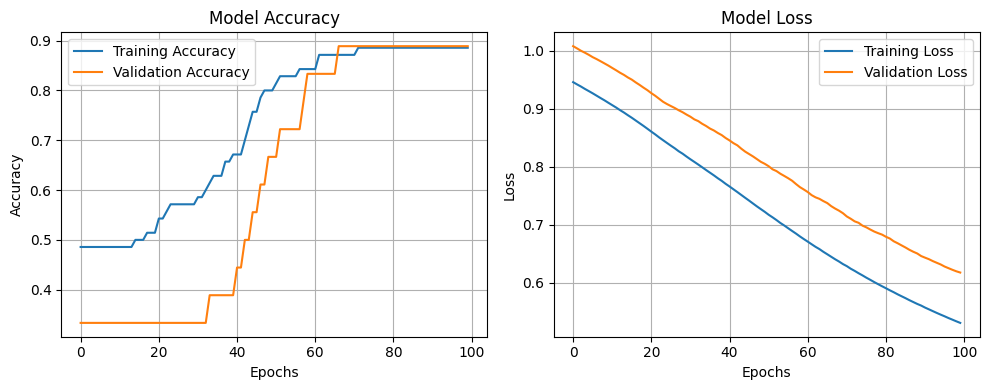

In [78]:
# evaluating, 

history = pd.DataFrame(history.history)
history # accuracy	loss	val_accuracy	val_loss

# Plot Accuracy
plt.figure(figsize=(10, 4))

plt.subplot(1,2,1)
plt.plot(history.accuracy, label = "Training Accuracy")
plt.plot(history.val_accuracy, label = "Validation Accuracy")
plt.title('Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.grid()
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.loss, label = "Training Loss" )
plt.plot(history.val_loss, label = "Validation Loss" )
plt.title('Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.grid()
plt.legend()

plt.tight_layout()
plt.show()

### Thus, we successfully, implemented a Neural Network, to learn from Iris dataset, and make predictions on it, with 95% accuracy

---

## **1. Build the Network**
- Initialize the model
- Compile the model:
    - To configure model settings
    - Optimizer - which optimizer to use
    - Loss - What loss function to use
    - metrics - which evaluation metric to use

2. Forward Propagation

3. Caculate the Loss

4. Back Propagation

5. Optimization - Weight Update - Gradient Decent 

6. Repeat (Epochs)